# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.680272118306016e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 3.865112e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738420e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


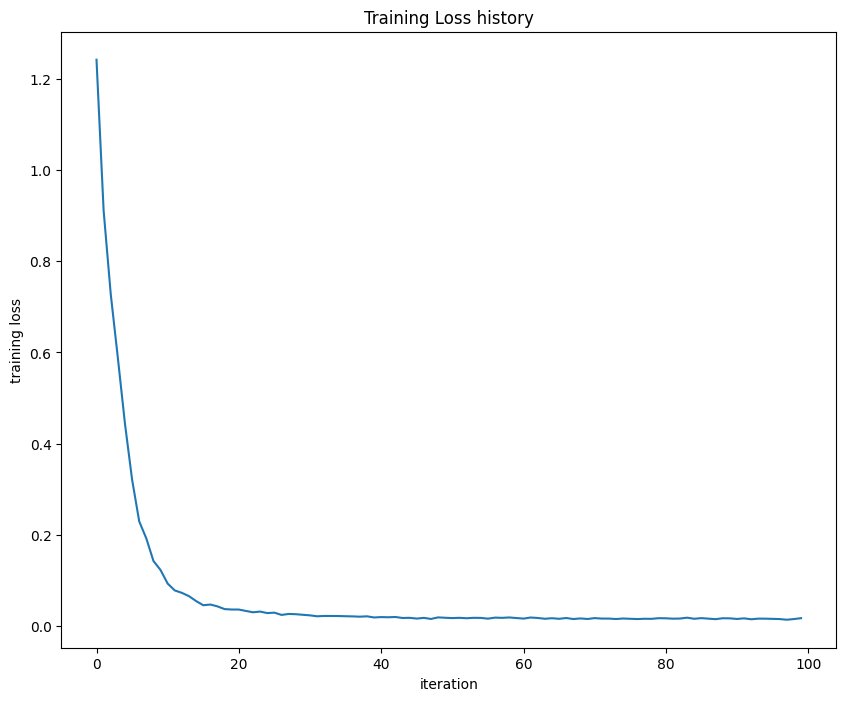

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
from scripts.data_utils import load_CIFAR10
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

/Users/george/PycharmProjects/AI/lab_1-2/scripts/data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


In [8]:
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

n_train = 10000
n_val = 2000
n_test = 5000

mask = range(n_train, n_train + n_val)
X_val = X_train[list(mask)]
y_val = y_train[list(mask)]

mask = range(n_train)
X_train = X_train[list(mask)]
y_train = y_train[list(mask)]

mask = range(n_test)
X_test = X_test[list(mask)]
y_test = y_test[list(mask)]


X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (10000, 3072)
Train labels shape:  (10000,)
Validation data shape:  (2000, 3072)
Validation labels shape:  (2000,)
Test data shape:  (5000, 3072)
Test labels shape:  (5000,)


In [9]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.303005
iteration 100 / 1000: loss 2.301621
iteration 200 / 1000: loss 2.276465
iteration 300 / 1000: loss 2.184720
iteration 400 / 1000: loss 2.060324
iteration 500 / 1000: loss 2.032033
iteration 600 / 1000: loss 2.000818
iteration 700 / 1000: loss 1.958863
iteration 800 / 1000: loss 2.055410
iteration 900 / 1000: loss 2.029082
Validation accuracy:  0.2775


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

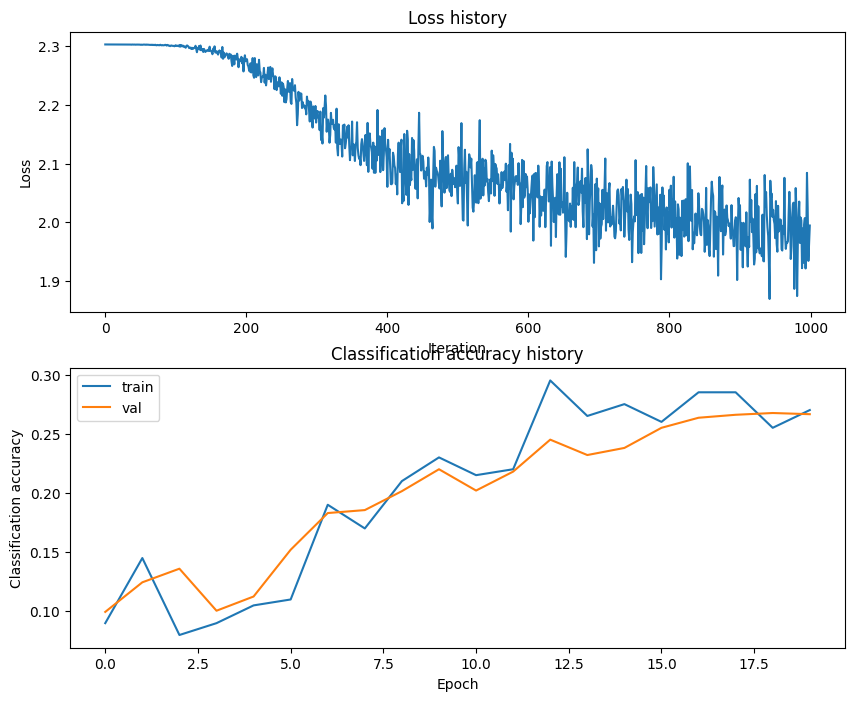

In [10]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

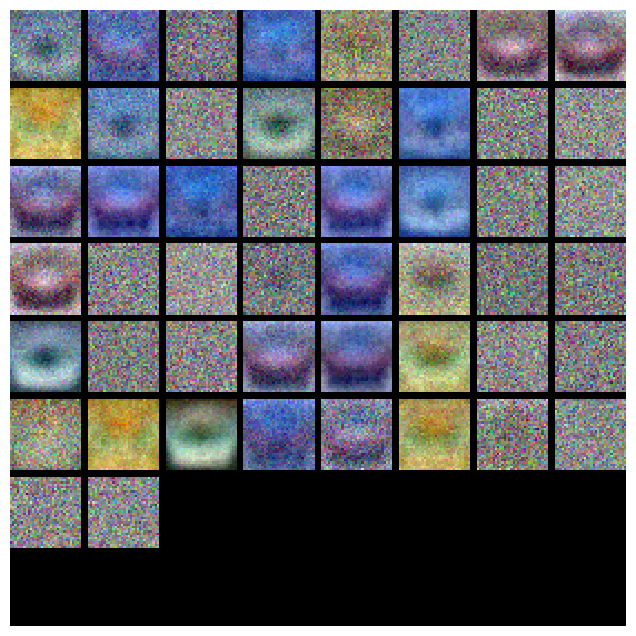

In [11]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

Повышение accuracy

In [12]:
X_train_tuned = X_train.copy()
X_val_tuned = X_val.copy()
X_test_tuned = X_test.copy()

mean_image_tuned = np.mean(X_train_tuned, axis=0)
X_train_tuned -= mean_image_tuned
X_val_tuned -= mean_image_tuned
X_test_tuned -= mean_image_tuned

input_size = 32 * 32 * 3
hidden_size = 100
num_classes = 10
net_tuned = TwoLayerNet(input_size, hidden_size, num_classes, std=1e-4)

stats_tuned = net_tuned.train(X_train_tuned, y_train, X_val_tuned, y_val,
            num_iters=1500, batch_size=200,
            learning_rate=1e-3, learning_rate_decay=0.95,
            reg=1e-4, verbose=True)

val_acc_tuned = (net_tuned.predict(X_val_tuned) == y_val).mean()
test_acc_tuned = (net_tuned.predict(X_test_tuned) == y_test).mean()

print('Validation accuracy (tuned): ', val_acc_tuned)
print('Test accuracy (tuned): ', test_acc_tuned)

iteration 0 / 1500: loss 2.302587
iteration 100 / 1500: loss 1.928741
iteration 200 / 1500: loss 1.697375
iteration 300 / 1500: loss 1.587537
iteration 400 / 1500: loss 1.495641
iteration 500 / 1500: loss 1.454653
iteration 600 / 1500: loss 1.470947
iteration 700 / 1500: loss 1.410805
iteration 800 / 1500: loss 1.365772
iteration 900 / 1500: loss 1.262622
iteration 1000 / 1500: loss 1.161041
iteration 1100 / 1500: loss 1.318423
iteration 1200 / 1500: loss 1.111249
iteration 1300 / 1500: loss 1.088120
iteration 1400 / 1500: loss 1.158305
Validation accuracy (tuned):  0.465
Test accuracy (tuned):  0.4652


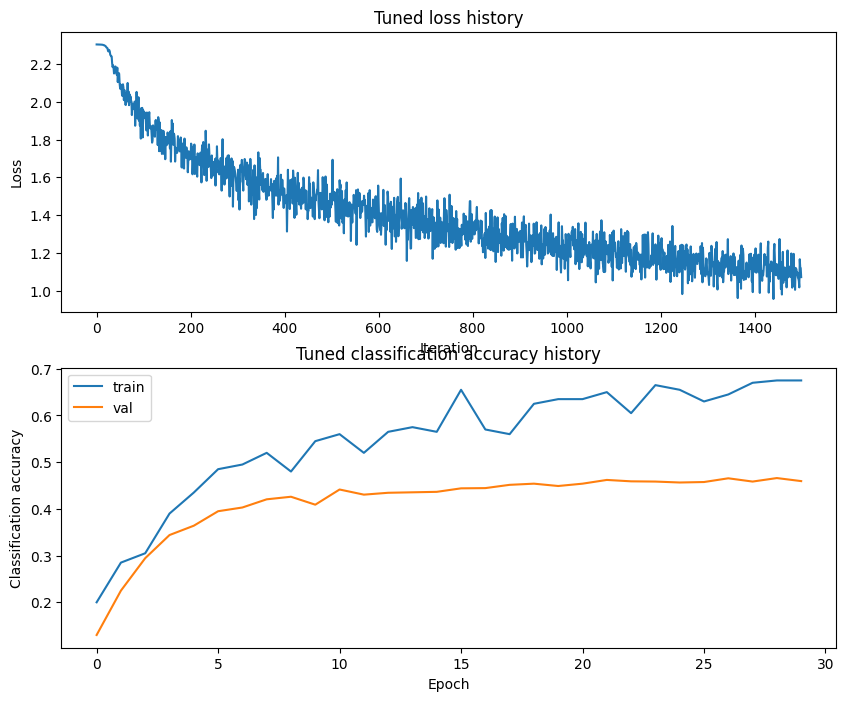

In [13]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(stats_tuned['loss_history'])
plt.title('Tuned loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats_tuned['train_acc_history'], label='train')
plt.plot(stats_tuned['val_acc_history'], label='val')
plt.title('Tuned classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

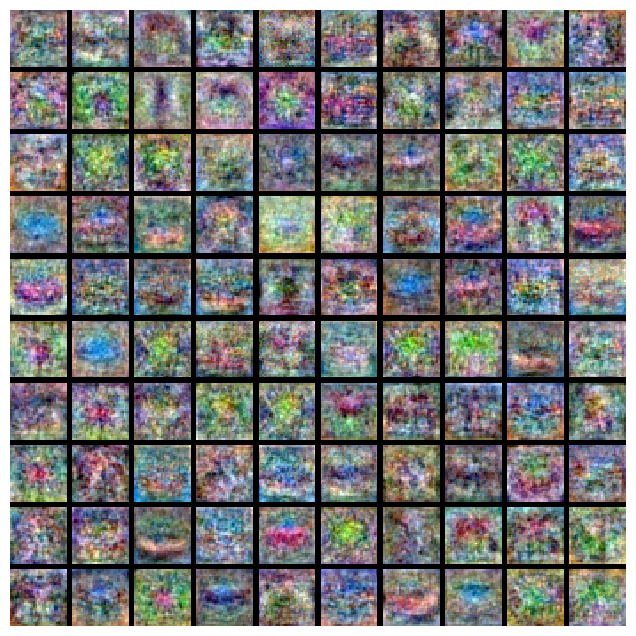

In [14]:
show_net_weights(net_tuned)

Сделайте выводы по результатам работы. 

В ходе лабораторной работы была реализована двухслойная полносвязная нейронная сеть для классификации изображений из набора CIFAR-10. Были реализованы основные этапы работы сети: прямой проход, вычисление функции потерь, обратное распространение ошибки, обучение модели и предсказание классов.

На модельных данных была проверена корректность реализации. Разница между рассчитанными оценками классов и эталонными значениями составила 3.68e-08, что говорит о правильной реализации прямого прохода. Разница между рассчитанным значением loss и эталоном составила 1.80e-13, то есть функция потерь также была реализована корректно.

По графику функции потерь видно, что loss в процессе обучения в целом уменьшается: с начального значения около 2.30 до значений примерно 1.1–1.2. Это означает, что модель действительно обучается и постепенно лучше подстраивает веса под данные. При этом точность на валидационной выборке после роста выходит на плато, что говорит об ограничении возможностей выбранной архитектуры.